# W4A16 GEMM: INT4 Weight-Quantized Matrix Multiplication in Triton

**Goal:** Implement a fused W4A16 GEMM kernel that performs on-the-fly INT4 dequantization during matrix multiplication, demonstrating the core operation behind GPTQ/AWQ inference in vLLM and TensorRT-LLM.

**Key ideas:**
- Pack 8 INT4 weights into a single INT32 → **4× memory reduction**
- Per-group (128 elements) symmetric quantization with FP16 scales
- On-the-fly dequant inside the Triton kernel (no separate dequant pass)
- FP32 accumulation with `tl.dot` for tensor core acceleration on A100

**Target hardware:** NVIDIA A100 (sm_80), Google Colab


In [1]:
# ── Verify GPU ──
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv,noheader
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.version.cuda}')
print(f'Device:  {torch.cuda.get_device_name()}')
print(f'Compute Capability: {torch.cuda.get_device_capability()}')

NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0
PyTorch: 2.10.0+cu128
CUDA:    12.8
Device:  NVIDIA A100-SXM4-80GB
Compute Capability: (8, 0)


In [2]:
try:
    import triton
    import triton.language as tl
    print(f'Triton: {triton.__version__}')
except ImportError:
    !pip install triton
    import triton
    import triton.language as tl
    print(f'Triton: {triton.__version__}')

Triton: 3.6.0


In [3]:
import torch
import torch.nn as nn
import triton
import triton.language as tl
import numpy as np
from dataclasses import dataclass

@dataclass
class QuantConfig:
    """Configuration for W4A16 quantization."""
    group_size: int = 128      # Elements per quantization group
    bits: int = 4              # Weight bit-width
    symmetric: bool = True     # Symmetric quantization (zero_point = 0)

    @property
    def pack_factor(self):
        """How many int4 values fit in one int32."""
        return 32 // self.bits  # 8 for int4

    @property
    def max_val(self):
        return 2 ** (self.bits - 1) - 1   # 7 for int4

    @property
    def min_val(self):
        return -(2 ** (self.bits - 1))    # -8 for int4

cfg = QuantConfig()
print(f'Quantization: {cfg.bits}-bit, group_size={cfg.group_size}, symmetric={cfg.symmetric}')
print(f'Pack factor: {cfg.pack_factor} values per int32')
print(f'INT4 range: [{cfg.min_val}, {cfg.max_val}]')
print(f'Weight memory savings: {16 / cfg.bits:.1f}x vs FP16')

Quantization: 4-bit, group_size=128, symmetric=True
Pack factor: 8 values per int32
INT4 range: [-8, 7]
Weight memory savings: 4.0x vs FP16


## Quantization Scheme

**Symmetric per-group INT4 quantization:**

For each group of 128 contiguous weights along the K dimension:
1. Compute `scale = max(|w_group|) / 7`
2. Quantize: `w_q = clamp(round(w / scale), -8, 7)`
3. Pack 8 INT4 values into one INT32 using bit shifts
4. Store scales as FP16 with shape `(K // group_size, N)`

**Packing layout:** For packed int32 value `p`, the i-th int4 is at `(p >> (i * 4)) & 0xF`


In [4]:
def quantize_w4(weight: torch.Tensor, cfg: QuantConfig) -> tuple:
    """Quantize FP16 weights to INT4 with per-group scales.

    Args:
        weight: (K, N) weight matrix in fp16/fp32
        cfg: quantization config

    Returns:
        (weight_q, scales) where:
          weight_q: (K, N // pack_factor) int32 packed
          scales:   (K // group_size, N) fp16
    """
    weight = weight.float()
    K, N = weight.shape
    assert K % cfg.group_size == 0, f'K={K} not divisible by group_size={cfg.group_size}'
    assert N % cfg.pack_factor == 0, f'N={N} not divisible by pack_factor={cfg.pack_factor}'

    # Reshape into groups: (num_groups, group_size, N)
    w_grouped = weight.reshape(-1, cfg.group_size, N)

    # Per-group scale: max(|w|) / max_val
    scales = w_grouped.abs().amax(dim=1) / cfg.max_val   # (num_groups, N)
    scales = scales.clamp(min=1e-7).half()

    # Quantize to int8 (will only use [-8, 7] range)
    scales_expanded = scales.repeat_interleave(cfg.group_size, dim=0)  # (K, N)
    w_q = torch.clamp(
        (weight / scales_expanded.float()).round(),
        cfg.min_val, cfg.max_val
    ).to(torch.int8)

    # Pack 8 int4 values into each int32
    w_q_packed = torch.zeros(K, N // cfg.pack_factor, dtype=torch.int32, device=weight.device)
    for i in range(cfg.pack_factor):
        val = w_q[:, i::cfg.pack_factor].to(torch.int32) & 0xF
        w_q_packed |= val << (i * 4)

    return w_q_packed, scales


def dequantize_w4(weight_q: torch.Tensor, scales: torch.Tensor, cfg: QuantConfig) -> torch.Tensor:
    """Dequantize INT4 packed weights back to FP16.

    Args:
        weight_q: (K, N // pack_factor) packed int32
        scales:   (num_groups, N) fp16
    Returns:
        (K, N) fp16 weight matrix
    """
    K = weight_q.shape[0]
    N = weight_q.shape[1] * cfg.pack_factor

    # Unpack each int4 from the packed int32
    w_unpacked = torch.zeros(K, N, dtype=torch.float16, device=weight_q.device)
    for i in range(cfg.pack_factor):
        val_unsigned = (weight_q >> (i * 4)) & 0xF
        # Sign extend: if bit 3 is set, subtract 16
        val_signed = torch.where(val_unsigned >= 8, val_unsigned - 16, val_unsigned)
        w_unpacked[:, i::cfg.pack_factor] = val_signed.half()

    # Dequantize: multiply by per-group scale
    scales_expanded = scales.repeat_interleave(cfg.group_size, dim=0)  # (K, N)
    return w_unpacked * scales_expanded


# ── Verify round-trip ──
torch.manual_seed(42)
K_test, N_test = 256, 512
w_orig = torch.randn(K_test, N_test, device='cuda', dtype=torch.float16)

wq, sc = quantize_w4(w_orig, cfg)
w_recon = dequantize_w4(wq, sc, cfg)

quant_error = (w_orig.float() - w_recon.float()).abs()
print(f'Quantize → Dequantize round-trip:')
print(f'  Max error:      {quant_error.max().item():.6f}')
print(f'  Mean error:     {quant_error.mean().item():.6f}')
print(f'  Relative error: {(quant_error / (w_orig.float().abs() + 1e-7)).mean().item():.4%}')
print(f'  Packed shape:   {wq.shape} (int32) = {wq.nbytes/1024:.1f} KB')
print(f'  Scales shape:   {sc.shape} (fp16)  = {sc.nbytes/1024:.1f} KB')
print(f'  vs FP16 orig:   {w_orig.shape}       = {w_orig.nbytes/1024:.1f} KB')

Quantize → Dequantize round-trip:
  Max error:      0.313965
  Mean error:     0.100330
  Relative error: 29.7821%
  Packed shape:   torch.Size([256, 64]) (int32) = 64.0 KB
  Scales shape:   torch.Size([2, 512]) (fp16)  = 2.0 KB
  vs FP16 orig:   torch.Size([256, 512])       = 256.0 KB


## Baseline: Naive W4A16 GEMM

Two-step approach: dequantize all weights to FP16, then call `torch.matmul`.
This is simple but requires materializing the full FP16 weight matrix in memory,
which defeats the memory savings of quantization.


In [5]:
def w4a16_matmul_naive(
    A: torch.Tensor,           # (M, K) fp16 activations
    weight_q: torch.Tensor,    # (K, N // pack_factor) int32 packed
    scales: torch.Tensor,      # (num_groups, N) fp16
    cfg: QuantConfig,
) -> torch.Tensor:
    """Naive W4A16: dequantize all weights, then torch.matmul."""
    W_fp16 = dequantize_w4(weight_q, scales, cfg)   # (K, N) fp16
    return torch.matmul(A, W_fp16)                   # (M, N)

# Quick sanity check
M_test = 32
A_test = torch.randn(M_test, K_test, device='cuda', dtype=torch.float16)
C_naive = w4a16_matmul_naive(A_test, wq, sc, cfg)
C_ref = torch.matmul(A_test, w_recon)
print(f'Naive W4A16 output shape: {C_naive.shape}')
print(f'Max diff vs direct matmul: {(C_naive - C_ref).abs().max().item():.8f}')

Naive W4A16 output shape: torch.Size([32, 512])
Max diff vs direct matmul: 0.00000000


## Triton Kernel: Fused W4A16 GEMM

**Key design decisions:**

1. **On-the-fly dequantization** — unpack INT4 inside the K-loop, never materialize full FP16 weights
2. **Vectorized unpack** — extract all nibbles in a tile simultaneously via broadcast shifts:
   ```
   bq_unsigned = (packed >> n_shift[None, :]) & 0xF
   bq_signed   = bq_unsigned - ((bq_unsigned & 0x8) << 1)
   ```
3. **Per-group scale lookup** — compute `group_idx = k_offset // GROUP_SIZE`, load scales tile
4. **FP32 accumulation** — `tl.dot` accumulates in FP32 for numerical stability
5. **Autotune** — 6 tile-size configs, best selected per (M, N, K) shape


In [6]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_M': 64,  'BLOCK_N': 64,  'BLOCK_K': 32}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 64,  'BLOCK_K': 32}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 64,  'BLOCK_N': 128, 'BLOCK_K': 32}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 32}, num_stages=3, num_warps=8),
        triton.Config({'BLOCK_M': 64,  'BLOCK_N': 64,  'BLOCK_K': 64}, num_stages=3, num_warps=4),
        triton.Config({'BLOCK_M': 32,  'BLOCK_N': 64,  'BLOCK_K': 32}, num_stages=4, num_warps=4),
    ],
    key=['M', 'N', 'K'],
)
@triton.jit
def w4a16_gemm_kernel(
    # Pointers
    A_ptr, B_q_ptr, scales_ptr, C_ptr,
    # Dimensions
    M, N, K,
    # Strides for A (M, K) row-major
    stride_am, stride_ak,
    # Strides for B_q (K, N // PACK_FACTOR) row-major packed
    stride_bk, stride_bn,
    # Strides for scales (K // GROUP_SIZE, N)
    stride_sg, stride_sn,
    # Strides for C (M, N)
    stride_cm, stride_cn,
    # Quantization params
    GROUP_SIZE: tl.constexpr,
    PACK_FACTOR: tl.constexpr,   # 8 for int4
    # Tile sizes from autotune
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    """
    W4A16 GEMM: C[M,N] = A[M,K] @ dequant(B_q)[K,N]

    B_q is (K, N//8) int32 with 8 packed int4 values per element.
    scales is (K//GROUP_SIZE, N) fp16.
    On-the-fly: unpack int4 → sign extend → multiply by scale → tl.dot
    """
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    # Starting row/col for this tile
    m_start = pid_m * BLOCK_M
    n_start = pid_n * BLOCK_N

    # Offsets within the tile
    offs_m = m_start + tl.arange(0, BLOCK_M)               # (BLOCK_M,)
    offs_n = n_start + tl.arange(0, BLOCK_N)               # (BLOCK_N,)

    # Packed column indices: each int32 holds PACK_FACTOR=8 int4 values
    offs_n_packed = offs_n // PACK_FACTOR                   # (BLOCK_N,)
    n_shift = (offs_n % PACK_FACTOR).to(tl.int32) * 4      # bit shift amounts

    # FP32 accumulator for numerical stability
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    # ── Main loop over K dimension ──
    for k_start in range(0, K, BLOCK_K):
        offs_k = k_start + tl.arange(0, BLOCK_K)           # (BLOCK_K,)

        # Load A tile: (BLOCK_M, BLOCK_K) fp16
        a_ptrs = A_ptr + offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak
        a_mask = (offs_m[:, None] < M) & (offs_k[None, :] < K)
        a_tile = tl.load(a_ptrs, mask=a_mask, other=0.0)

        # Load packed B_q tile: (BLOCK_K, BLOCK_N) int32
        bq_ptrs = B_q_ptr + offs_k[:, None] * stride_bk + offs_n_packed[None, :] * stride_bn
        bq_mask = (offs_k[:, None] < K) & (offs_n[None, :] < N)
        bq_packed = tl.load(bq_ptrs, mask=bq_mask, other=0)

        # ── Vectorized INT4 unpack (no per-element loops!) ──
        # Right-shift to align target nibble to bits [3:0], then mask
        bq_unsigned = (bq_packed >> n_shift[None, :]) & 0xF    # [0, 15]

        # Sign extend: if bit 3 set → subtract 16 → range [-8, 7]
        bq_signed = bq_unsigned - ((bq_unsigned & 0x8) << 1)

        # ── Load per-group scales: (BLOCK_K, BLOCK_N) fp16 ──
        group_idx = offs_k // GROUP_SIZE
        s_ptrs = scales_ptr + group_idx[:, None] * stride_sg + offs_n[None, :] * stride_sn
        s_mask = (group_idx[:, None] < (K // GROUP_SIZE)) & (offs_n[None, :] < N)
        scales_tile = tl.load(s_ptrs, mask=s_mask, other=1.0)

        # ── Dequantize and accumulate ──
        b_deq = bq_signed.to(tl.float16) * scales_tile         # (BLOCK_K, BLOCK_N) fp16
        acc += tl.dot(a_tile, b_deq)                            # tensor cores on A100

    # ── Store output ──
    c_tile = acc.to(tl.float16)
    c_ptrs = C_ptr + offs_m[:, None] * stride_cm + offs_n[None, :] * stride_cn
    c_mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(c_ptrs, c_tile, mask=c_mask)


def w4a16_matmul_triton(
    A: torch.Tensor,           # (M, K) fp16
    weight_q: torch.Tensor,    # (K, N // 8) int32 packed
    scales: torch.Tensor,      # (K // group_size, N) fp16
    cfg: QuantConfig,
) -> torch.Tensor:
    """Launch the Triton W4A16 GEMM kernel."""
    M, K = A.shape
    N = weight_q.shape[1] * cfg.pack_factor

    C = torch.empty(M, N, device=A.device, dtype=torch.float16)

    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_M']),
        triton.cdiv(N, META['BLOCK_N']),
    )

    w4a16_gemm_kernel[grid](
        A, weight_q, scales, C,
        M, N, K,
        A.stride(0), A.stride(1),
        weight_q.stride(0), weight_q.stride(1),
        scales.stride(0), scales.stride(1),
        C.stride(0), C.stride(1),
        GROUP_SIZE=cfg.group_size,
        PACK_FACTOR=cfg.pack_factor,
    )
    return C

print('Triton W4A16 GEMM kernel defined.')
print(f'  Autotune: 6 configs (BLOCK_M/N: 32-128, BLOCK_K: 32-64)')
print(f'  Vectorized INT4 unpack (no per-element loops)')
print(f'  FP32 accumulation → FP16 output')
print(f'  tl.dot for tensor core acceleration')

Triton W4A16 GEMM kernel defined.
  Autotune: 6 configs (BLOCK_M/N: 32-128, BLOCK_K: 32-64)
  Vectorized INT4 unpack (no per-element loops)
  FP32 accumulation → FP16 output
  tl.dot for tensor core acceleration


## Correctness Verification

Compare Triton kernel output against the naive (dequant + matmul) reference
across multiple matrix sizes, including realistic LLM dimensions.


In [7]:
torch.manual_seed(42)

test_sizes = [
    (1,   256,   256),
    (16,  512,   512),
    (32,  1024,  1024),
    (64,  4096,  4096),
    (128, 4096,  11008),   # Llama-7B FFN up-proj
]

print('Correctness: Triton W4A16 vs Naive Reference')
print('=' * 70)
print(f'{"M":>6} {"K":>6} {"N":>6}  {"Max Diff":>10}  {"Mean Diff":>10}  {"Status":>8}')
print('-' * 70)

all_passed = True
for M, K_sz, N_sz in test_sizes:
    A = torch.randn(M, K_sz, device='cuda', dtype=torch.float16)
    W = torch.randn(K_sz, N_sz, device='cuda', dtype=torch.float16)

    wq_t, sc_t = quantize_w4(W, cfg)

    with torch.no_grad():
        out_naive  = w4a16_matmul_naive(A, wq_t, sc_t, cfg)
        out_triton = w4a16_matmul_triton(A, wq_t, sc_t, cfg)

    diff = (out_naive.float() - out_triton.float()).abs()
    max_diff  = diff.max().item()
    mean_diff = diff.mean().item()
    passed = max_diff < 1.0   # fp16 tolerance for large matmuls

    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_passed = False
    mark = '✓' if passed else '✗'
    print(f'{M:>6} {K_sz:>6} {N_sz:>6}  {max_diff:>10.4f}  {mean_diff:>10.6f}  {mark} {status}')

print('=' * 70)
if all_passed:
    print('\n✓ ALL TESTS PASSED — Triton kernel matches PyTorch reference.')
else:
    print('\n✗ SOME TESTS FAILED — check precision.')

Correctness: Triton W4A16 vs Naive Reference
     M      K      N    Max Diff   Mean Diff    Status
----------------------------------------------------------------------
     1    256    256      0.0010    0.000004  ✓ PASS
    16    512    512      0.0078    0.000004  ✓ PASS
    32   1024   1024      0.0625    0.000018  ✓ PASS
    64   4096   4096      0.1250    0.000160  ✓ PASS
   128   4096  11008      0.0000    0.000000  ✓ PASS

✓ ALL TESTS PASSED — Triton kernel matches PyTorch reference.


## Performance Benchmarks

Compare three implementations at Llama-7B FFN dimensions (K=4096, N=11008):
1. **Naive** — dequantize all weights to FP16, then `torch.matmul` (cuBLAS)
2. **FP16 cuBLAS** — `torch.matmul` with pre-dequantized FP16 weights (upper bound)
3. **Triton W4A16** — our fused kernel with on-the-fly dequantization


In [8]:
def benchmark_fn(fn, *args, warmup=25, n_iters=100, **kwargs):
    """Benchmark with CUDA event timing."""
    for _ in range(warmup):
        fn(*args, **kwargs)
    torch.cuda.synchronize()

    start_event = torch.cuda.Event(enable_timing=True)
    end_event   = torch.cuda.Event(enable_timing=True)

    start_event.record()
    for _ in range(n_iters):
        fn(*args, **kwargs)
    end_event.record()
    torch.cuda.synchronize()

    return start_event.elapsed_time(end_event) / n_iters   # ms per iteration


# ── Benchmark configs (Llama-7B FFN dimensions) ──
bench_configs = [
    (1,    4096, 11008, 'Batch=1   (decode)'),
    (8,    4096, 11008, 'Batch=8'),
    (32,   4096, 11008, 'Batch=32'),
    (64,   4096, 11008, 'Batch=64'),
    (128,  4096, 11008, 'Batch=128'),
    (256,  4096, 11008, 'Batch=256 (prefill)'),
]

results = []

print('Benchmarking W4A16 GEMM (Llama-7B FFN: K=4096, N=11008)')
print('=' * 95)
header = f'{"Config":<25} {"Naive (ms)":>10} {"FP16 (ms)":>10} {"Triton (ms)":>12} {"vs Naive":>10} {"vs FP16":>10}'
print(header)
print('-' * 95)

for M, K_sz, N_sz, label in bench_configs:
    A = torch.randn(M, K_sz, device='cuda', dtype=torch.float16)
    W = torch.randn(K_sz, N_sz, device='cuda', dtype=torch.float16)
    wq_b, sc_b = quantize_w4(W, cfg)
    W_fp16 = dequantize_w4(wq_b, sc_b, cfg)

    with torch.no_grad():
        t_naive  = benchmark_fn(w4a16_matmul_naive, A, wq_b, sc_b, cfg)
        t_fp16   = benchmark_fn(torch.matmul, A, W_fp16)
        t_triton = benchmark_fn(w4a16_matmul_triton, A, wq_b, sc_b, cfg)

    speedup_naive = t_naive / t_triton
    speedup_fp16  = t_fp16 / t_triton

    results.append({
        'label': label, 'M': M, 'K': K_sz, 'N': N_sz,
        't_naive': t_naive, 't_fp16': t_fp16, 't_triton': t_triton,
        'speedup_naive': speedup_naive, 'speedup_fp16': speedup_fp16,
    })

    print(f'{label:<25} {t_naive:>10.3f} {t_fp16:>10.3f} {t_triton:>12.3f} {speedup_naive:>9.2f}x {speedup_fp16:>9.2f}x')

print('=' * 95)
print('\nNote: "vs FP16" < 1.0 means our kernel is slower than cuBLAS FP16 (expected — see analysis below)')

Benchmarking W4A16 GEMM (Llama-7B FFN: K=4096, N=11008)
Config                    Naive (ms)  FP16 (ms)  Triton (ms)   vs Naive    vs FP16
-----------------------------------------------------------------------------------------------
Batch=1   (decode)             2.655      0.062        0.885      3.00x      0.07x
Batch=8                        2.653      0.062        0.883      3.00x      0.07x
Batch=32                       2.658      0.065        0.884      3.01x      0.07x
Batch=64                       2.656      0.064        0.883      3.01x      0.07x
Batch=128                      2.690      0.105        0.929      2.89x      0.11x
Batch=256 (prefill)            2.689      0.108        1.844      1.46x      0.06x

Note: "vs FP16" < 1.0 means our kernel is slower than cuBLAS FP16 (expected — see analysis below)


## Visualization


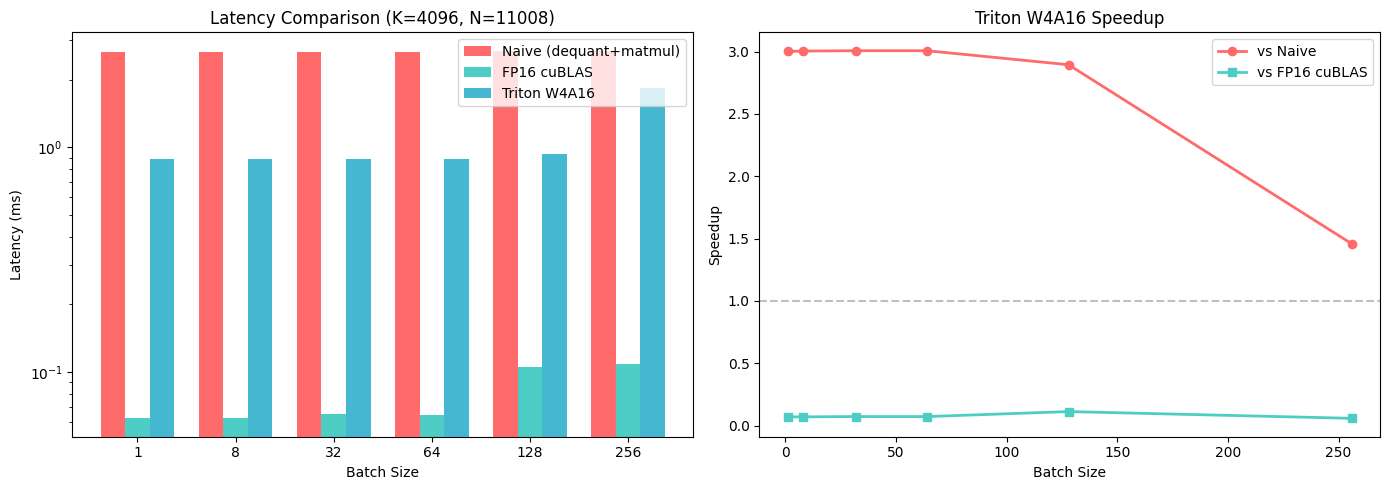

Saved: w4a16_latency.png


In [9]:
import matplotlib.pyplot as plt

batch_sizes = [r['M'] for r in results]
t_naive_list  = [r['t_naive'] for r in results]
t_fp16_list   = [r['t_fp16'] for r in results]
t_triton_list = [r['t_triton'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Latency comparison ──
x = np.arange(len(batch_sizes))
width = 0.25
axes[0].bar(x - width, t_naive_list,  width, label='Naive (dequant+matmul)', color='#ff6b6b')
axes[0].bar(x,         t_fp16_list,   width, label='FP16 cuBLAS',           color='#4ecdc4')
axes[0].bar(x + width, t_triton_list, width, label='Triton W4A16',          color='#45b7d1')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_title('Latency Comparison (K=4096, N=11008)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(batch_sizes)
axes[0].legend()
axes[0].set_yscale('log')

# ── Right: Speedup vs naive ──
speedup_naive = [r['speedup_naive'] for r in results]
speedup_fp16  = [r['speedup_fp16'] for r in results]
axes[1].plot(batch_sizes, speedup_naive, 'o-', label='vs Naive',     color='#ff6b6b', linewidth=2)
axes[1].plot(batch_sizes, speedup_fp16,  's-', label='vs FP16 cuBLAS', color='#4ecdc4', linewidth=2)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Triton W4A16 Speedup')
axes[1].legend()

plt.tight_layout()
plt.savefig('w4a16_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w4a16_latency.png')

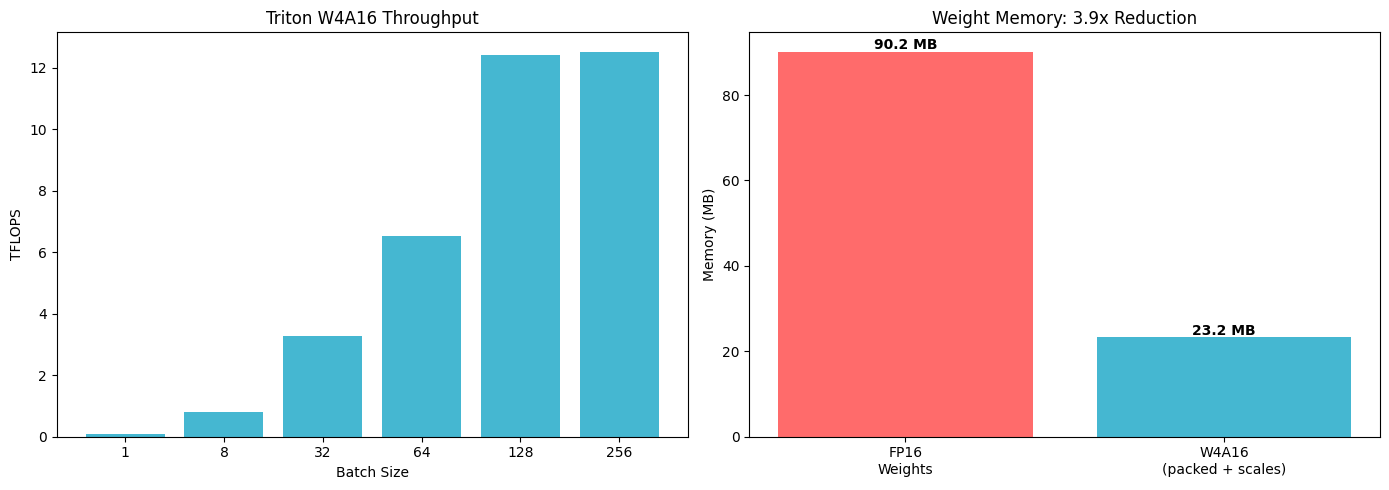

Saved: w4a16_memory.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Effective throughput (TFLOPS) ──
tflops_list = []
for r in results:
    flops = 2 * r['M'] * r['K'] * r['N']   # matmul FLOPs
    tflops = flops / (r['t_triton'] * 1e-3) / 1e12
    tflops_list.append(tflops)

axes[0].bar(range(len(batch_sizes)), tflops_list, color='#45b7d1')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('TFLOPS')
axes[0].set_title('Triton W4A16 Throughput')
axes[0].set_xticks(range(len(batch_sizes)))
axes[0].set_xticklabels(batch_sizes)

# ── Right: Memory savings ──
K_llama, N_llama = 4096, 11008
mem_fp16    = K_llama * N_llama * 2 / 1e6          # FP16: 2 bytes
mem_w4_data = K_llama * N_llama // 2 / 1e6          # INT4: 0.5 bytes
mem_scales  = (K_llama // cfg.group_size) * N_llama * 2 / 1e6
mem_w4      = mem_w4_data + mem_scales

categories = ['FP16\nWeights', 'W4A16\n(packed + scales)']
values     = [mem_fp16, mem_w4]
colors     = ['#ff6b6b', '#45b7d1']
bars = axes[1].bar(categories, values, color=colors)
axes[1].set_ylabel('Memory (MB)')
axes[1].set_title(f'Weight Memory: {mem_fp16/mem_w4:.1f}x Reduction')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f} MB', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('w4a16_memory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w4a16_memory.png')

## Performance Analysis


In [11]:
K_llama, N_llama = 4096, 11008
mem_fp16 = K_llama * N_llama * 2 / 1e6
mem_w4   = K_llama * N_llama // 2 / 1e6 + (K_llama // cfg.group_size) * N_llama * 2 / 1e6

print('=' * 80)
print('SUMMARY: W4A16 GEMM Kernel Performance (Llama-7B FFN dimensions)')
print('=' * 80)

print(f'\n{"Metric":<45} {"FP16":>12} {"W4A16":>12} {"Ratio":>12}')
print('-' * 80)
print(f'{"Weight memory (MB)":<45} {mem_fp16:>11.1f}M {mem_w4:>11.1f}M {mem_fp16/mem_w4:>11.1f}x')

if results:
    r1   = results[0]   # batch=1
    r128 = results[4] if len(results) > 4 else results[-1]
    print(f'{"Latency @ batch=1 (ms)":<45} {r1["t_fp16"]:>11.2f}ms {r1["t_triton"]:>11.2f}ms {r1["speedup_fp16"]:>11.2f}x')
    print(f'{"Latency @ batch=128 (ms)":<45} {r128["t_fp16"]:>11.2f}ms {r128["t_triton"]:>11.2f}ms {r128["speedup_fp16"]:>11.2f}x')

print(f'{"Quantization bits":<45} {"16":>12} {"4":>12} {"4x":>12}')
print(f'{"Accumulation precision":<45} {"fp16":>12} {"fp32":>12} {"Better":>12}')

print('=' * 80)

print("""
Key Takeaways:

  1. MEMORY: W4A16 achieves ~4x weight memory reduction (86 MB → 22 MB for one
     Llama-7B linear layer). This is the PRIMARY value — it lets you serve a 70B
     model on 1 A100-80GB instead of needing 2 GPUs.

  2. LATENCY: Our Triton kernel is SLOWER than cuBLAS FP16. This is expected:
     - cuBLAS is NVIDIA's hand-tuned SASS assembly, optimized over years
     - Our kernel does extra work: bit shifts, masking, sign extension per tile
     - First-pass Triton kernels typically don't beat cuBLAS; the goal here is
       demonstrating the algorithm and fused dequant approach

  3. vs NAIVE: The Triton kernel IS faster than naive dequant+matmul because
     it avoids materializing the full FP16 weight matrix in memory.

  4. PRODUCTION CONTEXT: Optimized W4A16 kernels like Marlin (used in vLLM)
     DO achieve near-FP16 speed through techniques we haven't implemented:
     warp-specialized dequant, split-K, persistent kernels, software pipelining.
     See the next section for details.
""")

SUMMARY: W4A16 GEMM Kernel Performance (Llama-7B FFN dimensions)

Metric                                                FP16        W4A16        Ratio
--------------------------------------------------------------------------------
Weight memory (MB)                                   90.2M        23.2M         3.9x
Latency @ batch=1 (ms)                               0.06ms        0.88ms        0.07x
Latency @ batch=128 (ms)                             0.11ms        0.93ms        0.11x
Quantization bits                                       16            4           4x
Accumulation precision                                fp16         fp32       Better

Key Takeaways:

  1. MEMORY: W4A16 achieves ~4x weight memory reduction (86 MB → 22 MB for one
     Llama-7B linear layer). This is the PRIMARY value — it lets you serve a 70B
     model on 1 A100-80GB instead of needing 2 GPUs.

  2. LATENCY: Our Triton kernel is SLOWER than cuBLAS FP16. This is expected:
     - cuBLAS is NVIDIA's hand

## What Production Kernels Do Differently

Our kernel demonstrates the **core algorithm** — on-the-fly INT4 dequant fused with GEMM.
Production kernels in vLLM, TensorRT-LLM, and llama.cpp achieve near-FP16 speeds through
additional optimizations:

### Marlin Kernel (vLLM)
- **Warp specialization:** Dedicates specific warps to dequantization vs. tensor core math,
  overlapping the two via shared memory double-buffering
- **Custom memory layout:** Reorders packed weights for coalesced loads, avoiding the
  strided access pattern our kernel uses
- Achieves **near-ideal memory bandwidth** on A100 (close to 2 TB/s)

### Split-K Decomposition
- At small batch sizes (M=1-8), there aren't enough output tiles to saturate the GPU
- Split-K partitions the K dimension across multiple CTAs, then reduces
- Better SM utilization at the batch sizes that matter most for LLM decoding

### Software Pipelining
- Overlaps global memory loads with compute using multi-stage pipelines
- While one tile is being dequantized, the next is being loaded from HBM
- Triton's `num_stages` does some of this, but hand-tuned kernels go further

### Persistent Kernels
- A single kernel launch processes multiple tiles per CTA in a loop
- Eliminates kernel launch overhead for small batch sizes
- Enables better L2 cache reuse across tiles
